# Jets Bills


this notebook shows some explorations ahead of jets bills on 9/14/25.

Bills -6.5. 

Big stories:
- jets overperformed w1 against steelers with a good running attack (but lost)
- bills struggled against the run against the ravens
- josh allen lead a great comeback against the ravens
- ed oliver is out, bills call up zion logue.


Expectations heading into the game:
- Bills need to be decent against the run, jets will try to do so.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Connect to the NFL database
db_path = Path('../data/nfl.duckdb')
conn = duckdb.connect(str(db_path))

print(f"Connected to database: {db_path}")
print("Database connection established successfully!")

Connected to database: ../data/nfl.duckdb
Database connection established successfully!


In [28]:
# parameters
down = 3
season = 2025
play_type = 'pass'
ydstogo = (0,100)

q = f"""

with plays as (
select posteam,
        defteam,
        down,
        season,
        ydstogo,
        play_type,
            epa > 0 as success
 from pbp 
        where 1=1
            and epa is not null
                --            and down = {down}
                and season = {season}
               -- and play_type = '{play_type}'
             --   and ydstogo between {ydstogo[0]} and {ydstogo[1]}
            )

select * from plays where play_type in ('run','pass')
            
            """
pd.read_sql(q,conn)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
df = pd.read_sql_query(q, conn)
#df.head()

df.head()

# median = df['success_rate'].median()

# q75 = df['success_rate'].quantile(0.75)
# q25 = df['success_rate'].quantile(0.25)

,posteam,defteam,down,season,ydstogo,play_type,success
0,ARI,NO,1.0,2025,10.0,run,False
1,ARI,NO,2.0,2025,7.0,pass,True
2,ARI,NO,1.0,2025,10.0,pass,False
3,ARI,NO,2.0,2025,21.0,run,False
4,ARI,NO,3.0,2025,23.0,run,False


In [33]:
w1= df.groupby(['posteam','down','play_type']).agg(
                                                success_rate=('success','mean'),
                                                ydstogo=('ydstogo','mean'),
                                                plays=('success','count')).reset_index()  

print(w1[w1['posteam']=='BUF'])


print(w1[w1['posteam']=='NYJ'])



   posteam  down play_type  success_rate    ydstogo  plays
19     BUF   1.0      pass      0.450000  10.000000     20
20     BUF   1.0       run      0.538462   8.230769     13
21     BUF   2.0      pass      0.562500   8.437500     16
22     BUF   2.0       run      0.500000   3.900000     10
23     BUF   3.0      pass      0.333333   7.666667      9
24     BUF   3.0       run      0.800000   1.400000      5
25     BUF   4.0      pass      1.000000   2.000000      1
    posteam  down play_type  success_rate    ydstogo  plays
156     NYJ   1.0      pass      0.666667  10.000000      9
157     NYJ   1.0       run      0.473684   9.736842     19
158     NYJ   2.0      pass      0.500000   6.500000      8
159     NYJ   2.0       run      0.400000   6.900000     10
160     NYJ   3.0      pass      0.600000   6.000000      5
161     NYJ   3.0       run      0.555556   5.222222      9
162     NYJ   4.0      pass      0.000000   3.000000      1
163     NYJ   4.0       run      1.000000   1.00

In [34]:
w1= df.groupby(['defteam','down','play_type']).agg(
                                                success_rate=('success','mean'),
                                                ydstogo=('ydstogo','mean'),
                                                plays=('success','count')).reset_index()  

print(w1[w1['defteam']=='BUF'])


print(w1[w1['defteam']=='NYJ'])

   defteam  down play_type  success_rate    ydstogo  plays
21     BUF   1.0      pass      0.750000  10.000000      8
22     BUF   1.0       run      0.470588  10.000000     17
23     BUF   2.0      pass      0.166667  10.333333      6
24     BUF   2.0       run      0.375000   6.250000      8
25     BUF   3.0      pass      0.428571   7.714286      7
26     BUF   3.0       run      1.000000  10.000000      4
    defteam  down play_type  success_rate   ydstogo  plays
152     NYJ   1.0      pass      0.384615  9.615385     13
153     NYJ   1.0       run      0.272727  9.363636     11
154     NYJ   2.0      pass      0.583333  9.500000     12
155     NYJ   2.0       run      0.428571  7.000000      7
156     NYJ   3.0      pass      0.333333  9.000000      9
157     NYJ   3.0       run      1.000000  1.000000      1


In [14]:
def rank_plot(df
            ,selected_team
            ,color='Blue'
            ,param_labels=[]):
    
    plt.figure(figsize=(3, 4.5))
    plt.rcParams.update({'font.size': 12,
                         'font.family': 'Times New Roman',})  # Set base font size
    # Create colors array - blue for selected team, gray for others
    colors = [color if team == selected_team else 'gray' for team in df['posteam']]

    # Create horizontal dot plot with team names on y-axis
    plt.scatter(df['success_rate'], range(len(df)), c=colors, s=20)

    # Add vertical lines for quartiles
    plt.axvline(x=q25
                , color='red'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Q1 ({q25:.3f})')
    plt.axvline(x=median
                , color='gray'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Median ({median:.3f})')
    plt.axvline(x=q75
                , color='green'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Q3 ({q75:.3f})')

    # Set y-axis labels with colors
    plt.yticks(range(len(df)), df['posteam'])
    plt.xlabel('Success rate')
    plt.title(f'{season} Success Rate - {down} Down, {play_type} ')
    plt.gca().invert_yaxis()  # Reverse order so best is on top
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.yticks(fontsize=8)

    return plt

<module 'matplotlib.pyplot' from '/Users/chris.fenton/projects/nfl_analysis/nfl_env/lib/python3.9/site-packages/matplotlib/pyplot.py'>

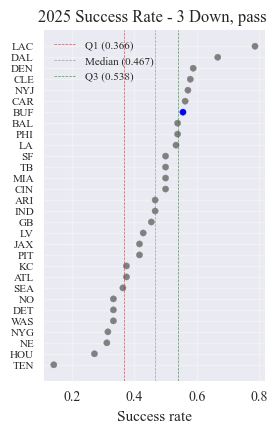

In [15]:
rank_plot(df,'BUF')



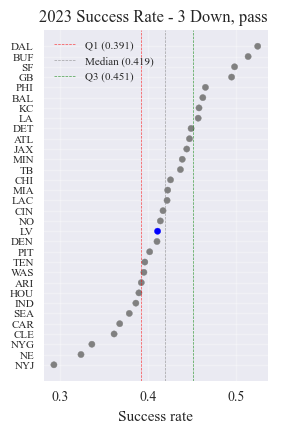

In [128]:
selected_team = 'LV'
color = 'blue'

# Create horizontal dot plot with team names on y-axis
plt.figure(figsize=(3, 4.5))
plt.rcParams.update({'font.size': 12,
'font.family': 'Times New Roman',})  # Set base font size
# Create colors array - blue for selected team, gray for others
colors = [color if team == selected_team else 'gray' for team in df['posteam']]

# Plot the dots
plt.scatter(df['success_rate'], range(len(df)), c=colors, s=20)

# Add vertical lines for quartiles
plt.axvline(x=q25
            , color='red'
            , linestyle='--'
            , alpha=0.7
            , linewidth=.5
            , label=f'Q1 ({q25:.3f})')
plt.axvline(x=median, color='gray', linestyle='--', alpha=0.7, linewidth=.5, label=f'Median ({median:.3f})')
plt.axvline(x=q75, color='green', linestyle='--', alpha=0.7, linewidth=.5, label=f'Q3 ({q75:.3f})')

# Set y-axis labels with colors
plt.yticks(range(len(df)), df['posteam'])
plt.xlabel('Success rate')
plt.title(f'{season} Success Rate - {down} Down, {play_type} ')
plt.gca().invert_yaxis()  # Reverse order so best is on top
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.yticks(fontsize=8)

plt.show()